# Importing Library

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Data


In [6]:
import pandas as pd

df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')

In [7]:
df.shape

(374, 13)

In [8]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


From that we know our data has 13 columns and 374 rows.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


# Data Understanding


In [ ]:
df.describe(include = 'all')

Let's check for any missing values.

In [20]:
df.isnull().sum()


,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


There are 219 rows in sleep disorder columns that have missing values.
But we dont drop the columns because that columns is indicate the person disorder.

## Frequency

In [27]:
df['Gender'].value_counts()

,count
Gender,
Male,189
Female,185


In this data there are more male respondent than female respondent.

In [33]:
df.iloc[:,3].value_counts()

,count
Occupation,
Nurse,73
Doctor,71
Engineer,63
Lawyer,47
Teacher,40
Accountant,37
Salesperson,32
Scientist,4
Software Engineer,4


According to this data the most common profession is nurse.

In [32]:
df.iloc[:,8].value_counts()

,count
BMI Category,
Normal,195
Overweight,148
Normal Weight,21
Obese,10


If we see based on the BMI Category average of people in this data have normal weight.

# Explanatory Data Analysis

### **Does Stress level affect Sleep Quality?**

Correlation Between Stress Level and Quality of Sleep
Correlation: -0.9


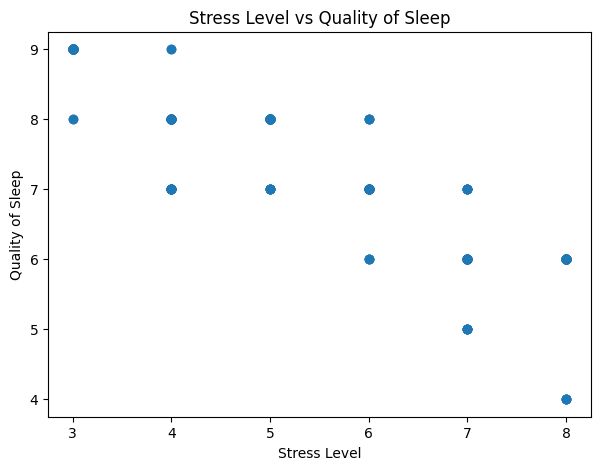

In [39]:
print("Correlation Between Stress Level and Quality of Sleep")
correlation = df["Stress Level"].corr(df["Quality of Sleep"])
print("Correlation:", round(correlation, 2))

plt.figure(figsize=(7,5))
plt.scatter(df["Stress Level"], df["Quality of Sleep"])
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.title("Stress Level vs Quality of Sleep")
plt.show()

From that we can conclude, Stress level is strongly negatively correlated with sleep quality (r = -0.9), indicating that individuals with higher stress levels tend to experience poorer sleep quality.



### **Which occupation has the worst sleep health?**

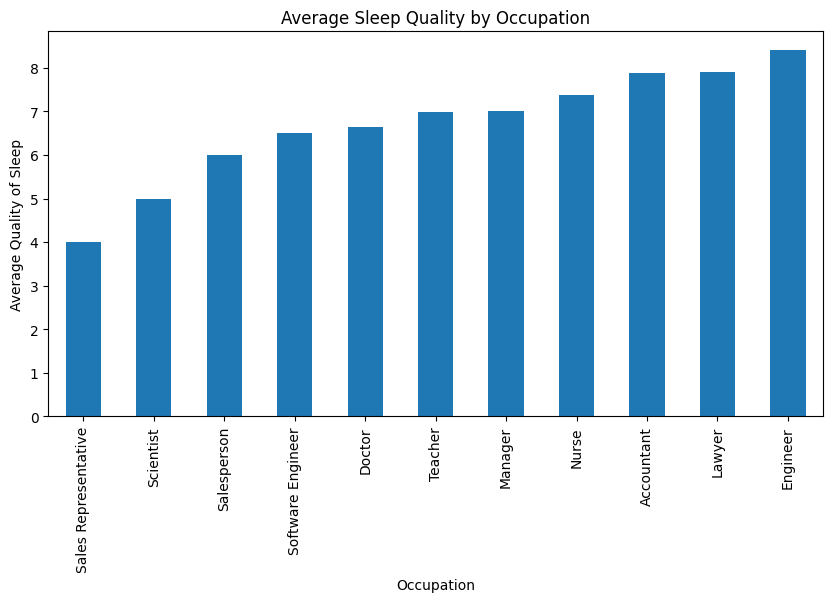

In [38]:
occupation_sleep = df.groupby("Occupation").agg({
    "Quality of Sleep":"mean",
    "Stress Level":"mean",
    "Sleep Duration":"mean"
}).sort_values(by="Quality of Sleep")

# print("\nOccupation Sleep Health Analysis")
# print(occupation_sleep)

plt.figure(figsize=(10,5))
occupation_sleep["Quality of Sleep"].plot(kind="bar")
plt.ylabel("Average Quality of Sleep")
plt.title("Average Sleep Quality by Occupation")
plt.show()

Based on occupation, sales representatives have the lowest average sleep quality, while engineers have the highest.

So we know that Differences in sleep quality across professions suggest that work patterns and job-related stress can affect a person’s sleep health.

### **Can physical activity improve sleep quality**


Correlation Between Physical Activity and Sleep Quality
Correlation: 0.19


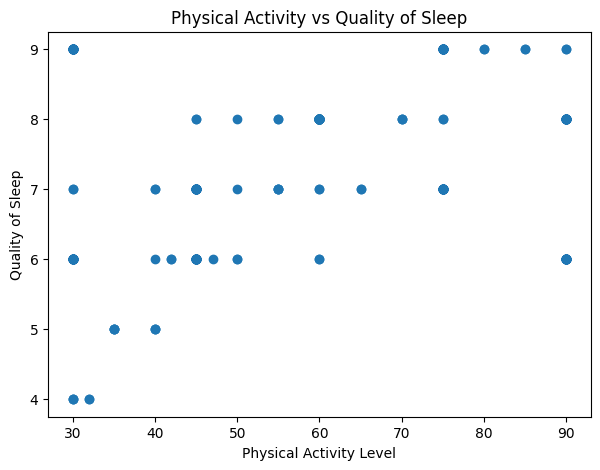

In [40]:
activity_corr = df["Physical Activity Level"].corr(df["Quality of Sleep"])

print("\nCorrelation Between Physical Activity and Sleep Quality")
print("Correlation:", round(activity_corr, 2))

plt.figure(figsize=(7,5))
plt.scatter(df["Physical Activity Level"], df["Quality of Sleep"])
plt.xlabel("Physical Activity Level")
plt.ylabel("Quality of Sleep")
plt.title("Physical Activity vs Quality of Sleep")
plt.show()

Based on above plot, Physical activity shows only a weak positive correlation with sleep quality (r = 0.19), suggesting that exercise alone may not significantly improve sleep quality.

### **What factors contribute to sleep disorders?**

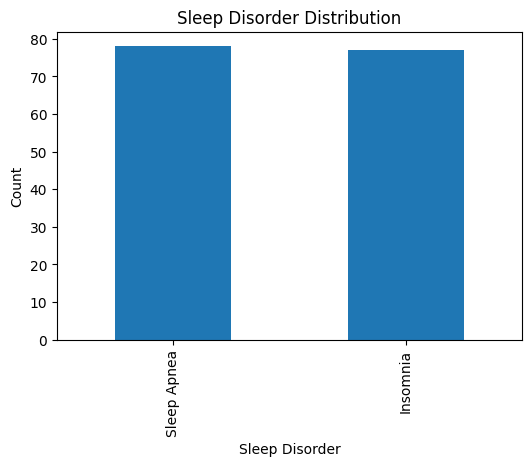

In [41]:
sleep_disorder_analysis = df.groupby("Sleep Disorder").agg({
    "Stress Level":"mean",
    "Sleep Duration":"mean",
    "BMI Category":lambda x: x.mode()[0],
    "Physical Activity Level":"mean",
    "Quality of Sleep":"mean"
})

sleep_disorder_count = df["Sleep Disorder"].value_counts()

plt.figure(figsize=(6,4))
sleep_disorder_count.plot(kind="bar")
plt.ylabel("Count")
plt.title("Sleep Disorder Distribution")
plt.show()

Of the 374 respondents, 219 did not have sleep disorders, and 155 were people with sleep disorders categorized as Sleep Apnea dan Imsonia.

### **How lifestyle impacts overall sleep health?**


Lifestyle Correlation Matrix
                         Sleep Duration  Quality of Sleep  Stress Level  \
Sleep Duration                 1.000000          0.883213     -0.811023   
Quality of Sleep               0.883213          1.000000     -0.898752   
Stress Level                  -0.811023         -0.898752      1.000000   
Physical Activity Level        0.212360          0.192896     -0.034134   
Daily Steps                   -0.039533          0.016791      0.186829   
Heart Rate                    -0.516455         -0.659865      0.670026   

                         Physical Activity Level  Daily Steps  Heart Rate  
Sleep Duration                          0.212360    -0.039533   -0.516455  
Quality of Sleep                        0.192896     0.016791   -0.659865  
Stress Level                           -0.034134     0.186829    0.670026  
Physical Activity Level                 1.000000     0.772723    0.136971  
Daily Steps                             0.772723     1.000000   

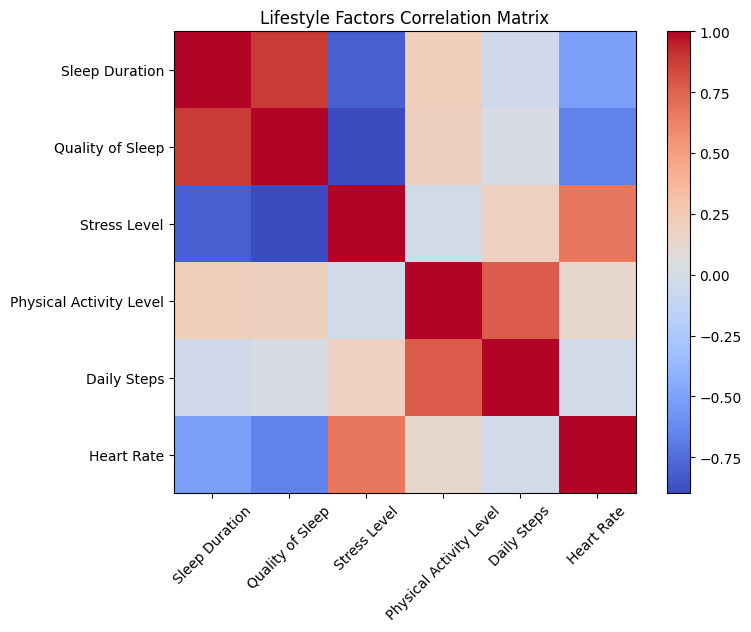

In [42]:
lifestyle_analysis = df[[
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Daily Steps",
    "Heart Rate"
]].corr()

print("\nLifestyle Correlation Matrix")
print(lifestyle_analysis)

plt.figure(figsize=(8,6))
plt.imshow(lifestyle_analysis, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(lifestyle_analysis.columns)),
           lifestyle_analysis.columns,
           rotation=45)

plt.yticks(range(len(lifestyle_analysis.columns)),
           lifestyle_analysis.columns)

plt.title("Lifestyle Factors Correlation Matrix")
plt.show()

We can conclude from the analysis reveals that stress level is the strongest factor associated with poor sleep quality, showing a very strong negative correlation (-0.90). Sleep duration also demonstrates a strong positive relationship with sleep quality (0.88), indicating that individuals who sleep longer tend to experience better sleep quality.

## Insights

In [44]:
# Highest stress occupation
highest_stress = df.groupby("Occupation")["Stress Level"].mean().idxmax()
print("Occupation with highest stress:", highest_stress)

# Best sleep quality occupation
best_sleep = df.groupby("Occupation")["Quality of Sleep"].mean().idxmax()
print("Occupation with best sleep quality:", best_sleep)

# Average sleep duration
avg_sleep = df["Sleep Duration"].mean()
print("Average sleep duration:", round(avg_sleep,2), "hours")

# Most common sleep disorder
most_common_disorder = df["Sleep Disorder"].mode()[0]
print("Most common sleep disorder:", most_common_disorder)

Occupation with highest stress: Sales Representative
Occupation with best sleep quality: Engineer
Average sleep duration: 7.13 hours
Most common sleep disorder: Sleep Apnea
